# 🧠 Brain Tumor Detection using MRI Images
### Transfer Learning with ResNet18, DenseNet121, and MobileNetV2

**Classes:** `glioma` | `meningioma` | `pituitary` | `no tumor`

**Pipeline:** Data Loading → Augmentation → Training → Evaluation → Grad-CAM → Ensemble

## Step 1: Install Required Libraries

In [11]:
!pip install torch torchvision matplotlib seaborn scikit-learn pillow grad-cam -q
print("✅ All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 88.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ All libraries installed!


## Step 2: Import Libraries

In [12]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cpu


## Step 3: Dataset Paths & Configuration

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Testing.zip to Testing.zip
Saving Training.zip to Training.zip


In [4]:
!mkdir -p /content/dataset/Training
!mkdir -p /content/dataset/Testing
!unzip Training.zip -d /content/dataset/Training
!unzip Testing.zip  -d /content/dataset/Testing

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_465.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_466.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_467.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_468.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_469.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_47.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_470.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_471.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_472.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_473.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_474.jpg  
  inflating: /content/dataset/Training/Training/meningioma/Tr-me_475.jpg  
  inflating: /content/dataset/Training/Training/me

In [19]:
!rm -rf /content/dataset/Testing/Testing
!rm -rf /content/dataset/Training/Training
TRAIN_DIR = "/content/dataset/Training"
TEST_DIR  = "/content/dataset/Testing"

In [21]:
import os

# ─── CONFIGURE THIS ────────────────────────────────────────────────────────────
DATA_ROOT = "/content/dataset"
# ───────────────────────────────────────────────────────────────────────────────

# 🔍 Auto-detect correct Training & Testing folders
def find_actual_path(base_path, folder_name):
    for root, dirs, files in os.walk(base_path):
        if folder_name in root:
            return root
    return None

TRAIN_DIR = find_actual_path(DATA_ROOT, "Training")
TEST_DIR  = find_actual_path(DATA_ROOT, "Testing")

# ❗ Safety check
if TRAIN_DIR is None or TEST_DIR is None:
    raise Exception("❌ Could not find Training/Testing folders. Check dataset structure.")

# Hyperparameters
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_EPOCHS  = 7
LEARNING_RATE = 1e-3

# ✅ Get class names
CLASS_NAMES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

NUM_CLASSES = len(CLASS_NAMES)

# ✅ Print info
print(f"Training path   : {TRAIN_DIR}")
print(f"Testing path    : {TEST_DIR}")
print(f"Classes found   : {CLASS_NAMES}")
print(f"Number of classes: {NUM_CLASSES}")

# ✅ Count images
def count_images(path):
    return sum(len(files) for _, _, files in os.walk(path))

print(f"📊 Training images : {count_images(TRAIN_DIR)}")
print(f"📊 Testing images  : {count_images(TEST_DIR)}")

Training path   : /content/dataset/Training
Testing path    : /content/dataset/Testing
Classes found   : ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
📊 Training images : 5600
📊 Testing images  : 1600


## Step 4: Data Loading & Augmentation

In [22]:
# ── Transforms ─────────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Datasets ───────────────────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=test_transforms)

# 80/20 train-val split from training data
val_size   = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# ── DataLoaders ────────────────────────────────────────────────────────────────
train_loader = DataLoader(train_subset,  batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_subset,    batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"✅ Train samples   : {train_size}")
print(f"✅ Val samples     : {val_size}")
print(f"✅ Test samples    : {len(test_dataset)}")

✅ Train samples   : 4480
✅ Val samples     : 1120
✅ Test samples    : 1600


### Visualise Sample Training Images

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


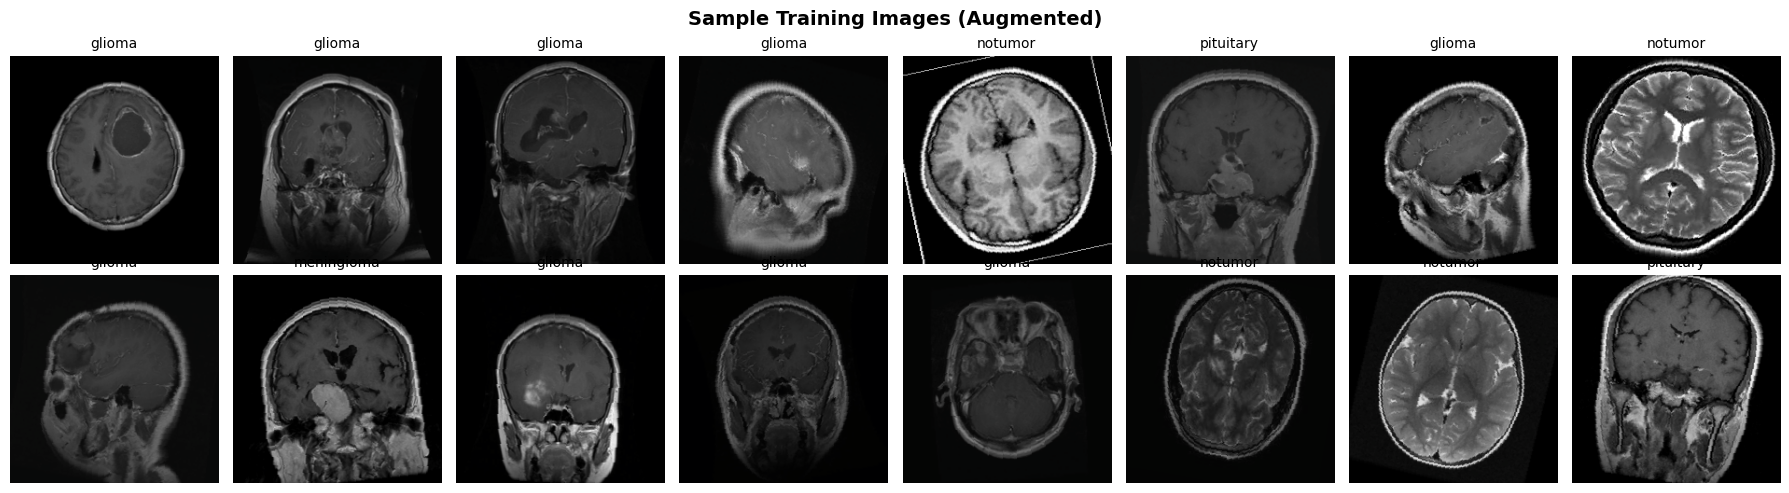

In [23]:
def imshow(tensor, title=None):
    """Un-normalize and display a tensor image."""
    img = tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title, fontsize=10)
    plt.axis("off")

# Show one batch
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle("Sample Training Images (Augmented)", fontsize=14, fontweight="bold")
for idx, ax in enumerate(axes.flat):
    if idx < len(images):
        plt.sca(ax)
        imshow(images[idx], title=CLASS_NAMES[labels[idx]])
plt.tight_layout()
plt.show()

## Step 5: Model Builder (Transfer Learning)

In [24]:
def build_model(name: str, num_classes: int = NUM_CLASSES) -> nn.Module:
    """
    Load a pretrained model, freeze ALL layers except the final
    classifier head, and replace it for `num_classes` outputs.
    """
    if name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False          # Freeze backbone
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    elif name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    elif name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
    else:
        raise ValueError(f"Unknown model: {name}")

    return model.to(DEVICE)

# Quick sanity check
tmp = build_model("resnet18")
total   = sum(p.numel() for p in tmp.parameters())
trainable = sum(p.numel() for p in tmp.parameters() if p.requires_grad)
print(f"ResNet18  — Total params: {total:,} | Trainable: {trainable:,}")
del tmp

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


ResNet18  — Total params: 11,178,564 | Trainable: 2,052


## Step 6: Training Loop

In [25]:
import shutil, os

for split in ["Training", "Testing"]:
    for item in os.listdir(f"/content/dataset/{split}"):
        full_path = f"/content/dataset/{split}/{item}"
        if item.startswith(".") or item == "__MACOSX" or not os.path.isdir(full_path):
            shutil.rmtree(full_path, ignore_errors=True)
            print(f"Removed: {full_path}")

# Verify
for split in ["Training", "Testing"]:
    print(f"{split}: {sorted(os.listdir(f'/content/dataset/{split}'))}")

Training: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [26]:
def train_model(model, model_name, num_epochs=NUM_EPOCHS):
    """
    Train a model and track loss/accuracy for each epoch.
    Returns the best model weights and history dict.
    """
    criterion = nn.CrossEntropyLoss()
    # Only optimise the trainable (head) parameters
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )
    # Reduce LR when val_loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=2, factor=0.5
    )

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    best_acc    = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    print(f"\n{'='*55}")
    print(f"  Training: {model_name.upper()}")
    print(f"{'='*55}")

    for epoch in range(num_epochs):
        start = time.time()

        # ── Training phase ───────────────────────────────────────
        model.train()
        train_loss, train_correct = 0.0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        # ── Validation phase ─────────────────────────────────────
        model.eval()
        val_loss, val_correct = 0.0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        # ── Epoch metrics ────────────────────────────────────────
        t_loss = train_loss / train_size
        v_loss = val_loss   / val_size
        t_acc  = train_correct / train_size * 100
        v_acc  = val_correct   / val_size   * 100

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        scheduler.step(v_loss)

        elapsed = time.time() - start
        print(f"  Epoch [{epoch+1:02d}/{num_epochs}] "
              f"| T-Loss: {t_loss:.4f}  T-Acc: {t_acc:.2f}%  "
              f"| V-Loss: {v_loss:.4f}  V-Acc: {v_acc:.2f}%  "
              f"| {elapsed:.1f}s")

        if v_acc > best_acc:
            best_acc     = v_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    print(f"\n  ✅ Best Val Accuracy: {best_acc:.2f}%")
    return model, history

print("Training loop defined ✅")

Training loop defined ✅


## Step 7: Train All Three Models

In [27]:
NUM_EPOCHS = 2
IMG_SIZE = 128
BATCH_SIZE = 8
model_name = "resnet18"

print(f"\n🚀 Training {model_name}...\n")

model = build_model(model_name)
model, history = train_model(model, model_name, num_epochs=2)

torch.save(model.state_dict(), "resnet18.pth")

print("✅ ResNet18 training completed & saved!")


🚀 Training resnet18...


  Training: RESNET18
  Epoch [01/2] | T-Loss: 0.8204  T-Acc: 67.21%  | V-Loss: 0.5040  V-Acc: 82.50%  | 556.3s
  Epoch [02/2] | T-Loss: 0.5990  T-Acc: 77.41%  | V-Loss: 0.4550  V-Acc: 82.14%  | 540.9s

  ✅ Best Val Accuracy: 82.50%
✅ ResNet18 training completed & saved!


In [28]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 2
model_name = "mobilenet_v2"

print(f"\n🚀 Training {model_name}...\n")

model = build_model(model_name)
model, history = train_model(model, model_name, num_epochs=2)

torch.save(model.state_dict(), "mobilenet_v2.pth")

print("✅ MobileNetV2 training completed & saved!")


🚀 Training mobilenet_v2...

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 171MB/s]



  Training: MOBILENET_V2
  Epoch [01/2] | T-Loss: 0.7725  T-Acc: 73.79%  | V-Loss: 0.5606  V-Acc: 82.59%  | 459.0s
  Epoch [02/2] | T-Loss: 0.5349  T-Acc: 81.07%  | V-Loss: 0.4834  V-Acc: 83.48%  | 457.1s

  ✅ Best Val Accuracy: 83.48%
✅ MobileNetV2 training completed & saved!


In [31]:
MODEL_NAMES = ["resnet18", "mobilenet_v2", "densenet121"]
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 1
model_name = "densenet121"

print(f"\n🚀 Training {model_name}...\n")

model = build_model(model_name)
model, history = train_model(model, model_name, num_epochs=1)

torch.save(model.state_dict(), "densenet121.pth")

print("✅ DenseNet121 training completed & saved!")


🚀 Training densenet121...


  Training: DENSENET121
  Epoch [01/1] | T-Loss: 0.7761  T-Acc: 70.38%  | V-Loss: 0.4648  V-Acc: 84.11%  | 1386.4s

  ✅ Best Val Accuracy: 84.11%
✅ DenseNet121 training completed & saved!


In [32]:
torch.save(history, "resnet18_history.pth")
torch.save(history, "mobilenet_v2_history.pth")
torch.save(history, "densenet121_history.pth")

In [33]:
import torch

training_history = {
    "resnet18": torch.load("resnet18_history.pth"),
    "mobilenet_v2": torch.load("mobilenet_v2_history.pth"),
    "densenet121": torch.load("densenet121_history.pth")
}

## Step 8: Training Curves

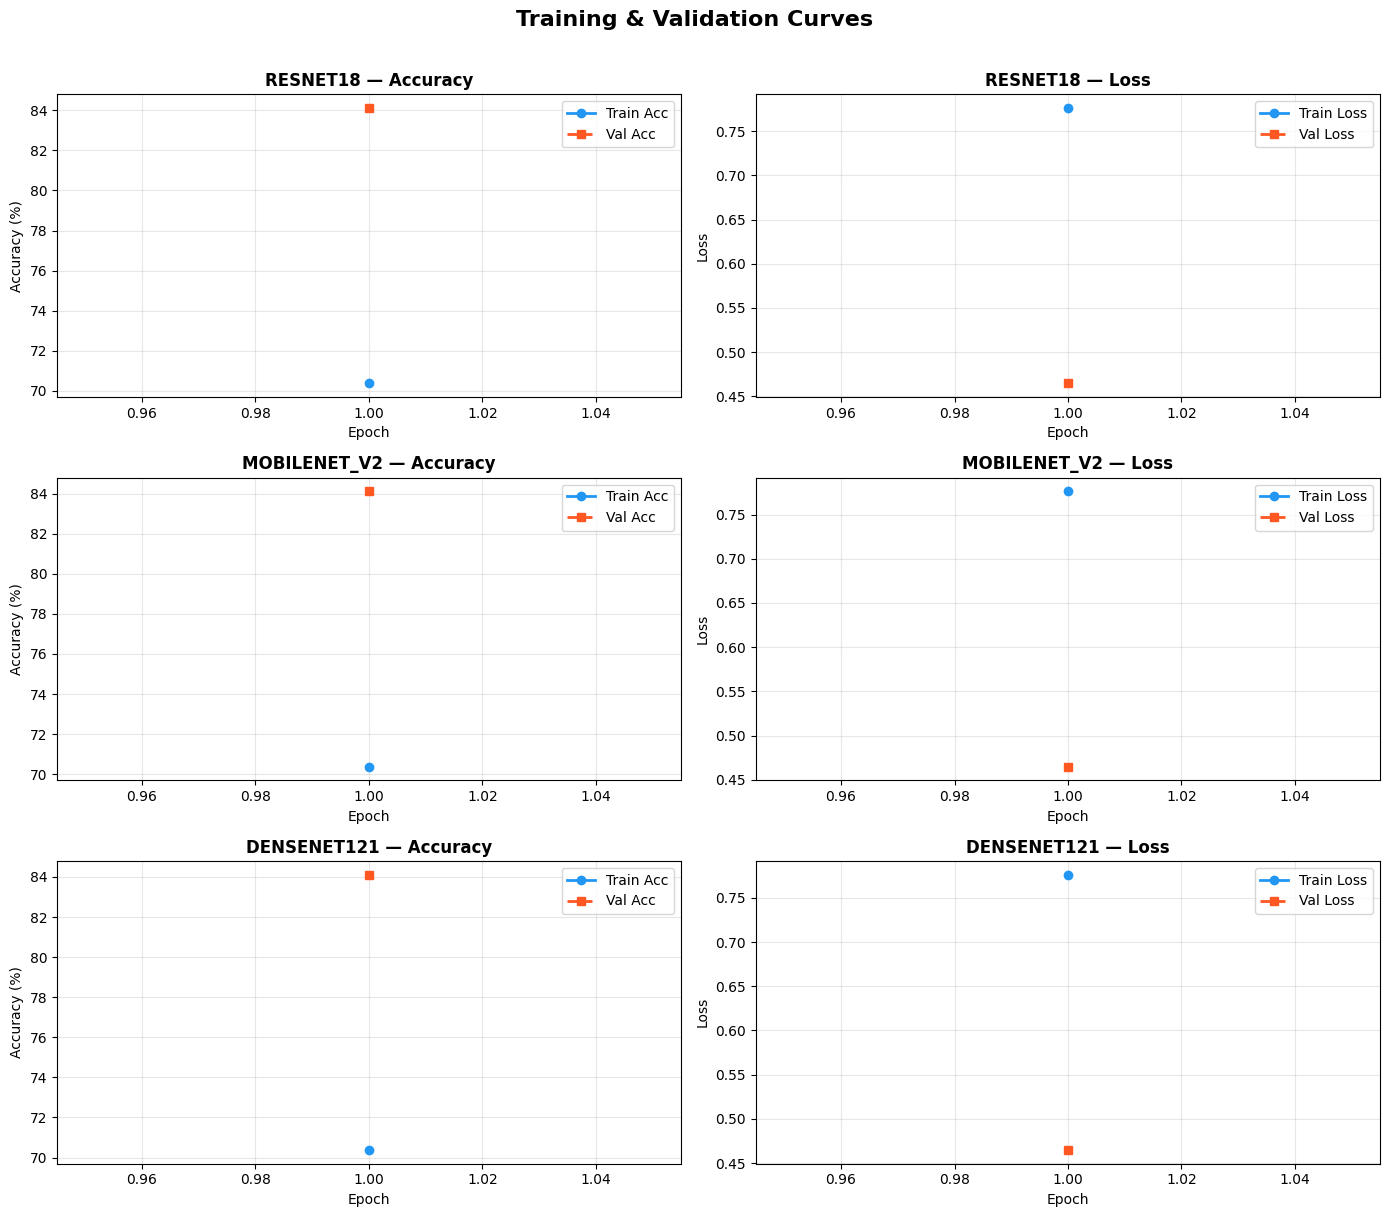

aved: training_curves.png


In [34]:
fig, axes = plt.subplots(len(MODEL_NAMES), 2, figsize=(14, 4 * len(MODEL_NAMES)))
fig.suptitle("Training & Validation Curves", fontsize=16, fontweight="bold", y=1.01)

colors = {"train": "#2196F3", "val": "#FF5722"}
epochs_range = range(1, NUM_EPOCHS + 1)

for row, name in enumerate(MODEL_NAMES):
    h = training_history[name]

    # Accuracy
    ax = axes[row][0]
    ax.plot(epochs_range, h["train_acc"], color=colors["train"], lw=2,
            marker="o", label="Train Acc")
    ax.plot(epochs_range, h["val_acc"],   color=colors["val"],   lw=2,
            marker="s", linestyle="--", label="Val Acc")
    ax.set_title(f"{name.upper()} — Accuracy", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(); ax.grid(alpha=0.3)

    # Loss
    ax = axes[row][1]
    ax.plot(epochs_range, h["train_loss"], color=colors["train"], lw=2,
            marker="o", label="Train Loss")
    ax.plot(epochs_range, h["val_loss"],   color=colors["val"],   lw=2,
            marker="s", linestyle="--", label="Val Loss")
    ax.set_title(f"{name.upper()} — Loss", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("aved: training_curves.png")

In [35]:
trained_models = {}

MODEL_NAMES = ["resnet18", "mobilenet_v2", "densenet121"]

for name in MODEL_NAMES:
    print(f"Loading {name}...")

    model = build_model(name)
    model.load_state_dict(torch.load(f"{name}.pth"))
    model.eval()

    trained_models[name] = model

print("✅ Models loaded")

Loading resnet18...
Loading mobilenet_v2...
Loading densenet121...
✅ Models loaded


## Step 9: Evaluate on Test Set

In [36]:
def evaluate_model(model, loader):
    """Run inference; return all true labels and predicted labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


test_results = {}
for name, model in trained_models.items():
    y_true, y_pred = evaluate_model(model, test_loader)
    acc = accuracy_score(y_true, y_pred) * 100
    test_results[name] = {"y_true": y_true, "y_pred": y_pred, "acc": acc}
    print(f"\n{'─'*50}")
    print(f"  Model : {name.upper()}")
    print(f"  Test Accuracy: {acc:.2f}%")
    print(f"{'─'*50}")
    print(classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4
    ))


──────────────────────────────────────────────────
  Model : RESNET18
  Test Accuracy: 77.38%
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.7627    0.7150    0.7381       400
  meningioma     0.7236    0.4975    0.5896       400
     notumor     0.7720    0.9650    0.8578       400
   pituitary     0.8156    0.9175    0.8635       400

    accuracy                         0.7738      1600
   macro avg     0.7685    0.7737    0.7623      1600
weighted avg     0.7685    0.7738    0.7623      1600



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



──────────────────────────────────────────────────
  Model : MOBILENET_V2
  Test Accuracy: 77.69%
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.8638    0.5550    0.6758       400
  meningioma     0.6155    0.7325    0.6689       400
     notumor     0.7962    0.9475    0.8653       400
   pituitary     0.8926    0.8725    0.8824       400

    accuracy                         0.7769      1600
   macro avg     0.7920    0.7769    0.7731      1600
weighted avg     0.7920    0.7769    0.7731      1600



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



──────────────────────────────────────────────────
  Model : DENSENET121
  Test Accuracy: 77.75%
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.7601    0.7525    0.7563       400
  meningioma     0.7384    0.5150    0.6068       400
     notumor     0.7815    0.9925    0.8744       400
   pituitary     0.8153    0.8500    0.8323       400

    accuracy                         0.7775      1600
   macro avg     0.7738    0.7775    0.7675      1600
weighted avg     0.7738    0.7775    0.7675      1600



## Step 10: Confusion Matrices

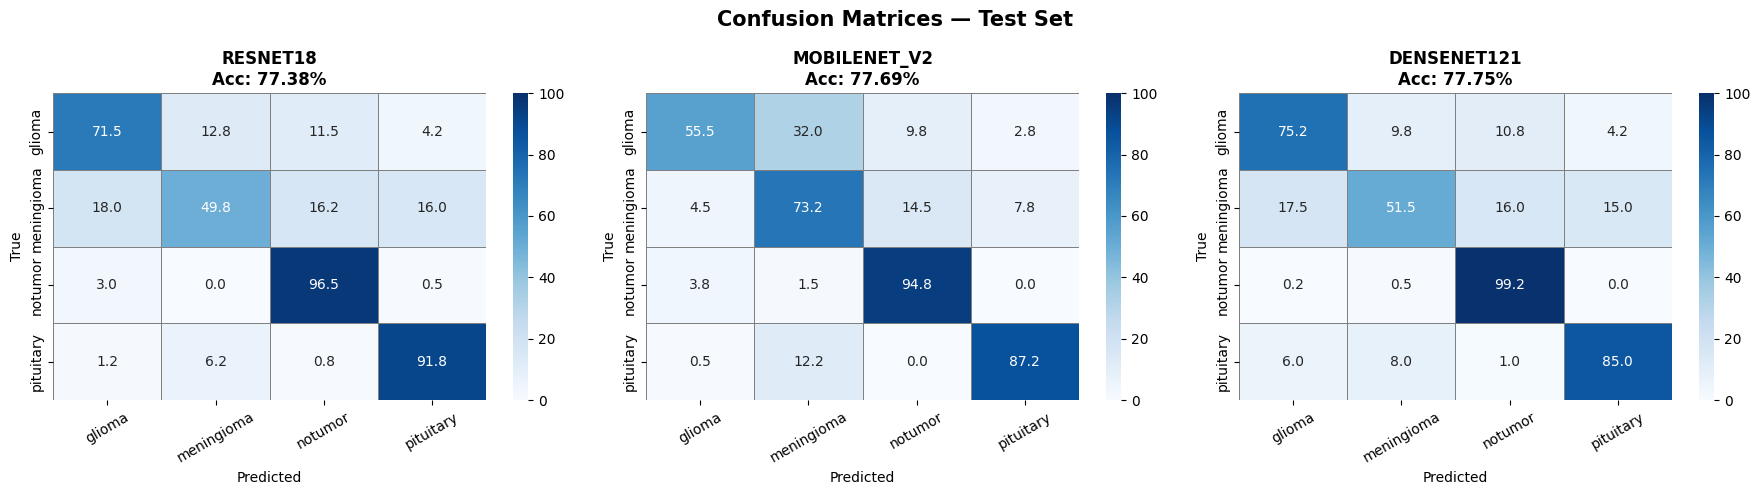

📁 Saved: confusion_matrices.png


In [37]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(18, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=15, fontweight="bold")

for ax, name in zip(axes, MODEL_NAMES):
    r   = test_results[name]
    cm  = confusion_matrix(r["y_true"], r["y_pred"])
    # Normalise row-wise so colours show recall per class
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor="grey", ax=ax,
        vmin=0, vmax=100
    )
    ax.set_title(f"{name.upper()}\nAcc: {r['acc']:.2f}%", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved: confusion_matrices.png")

## Step 11: Model Accuracy Comparison

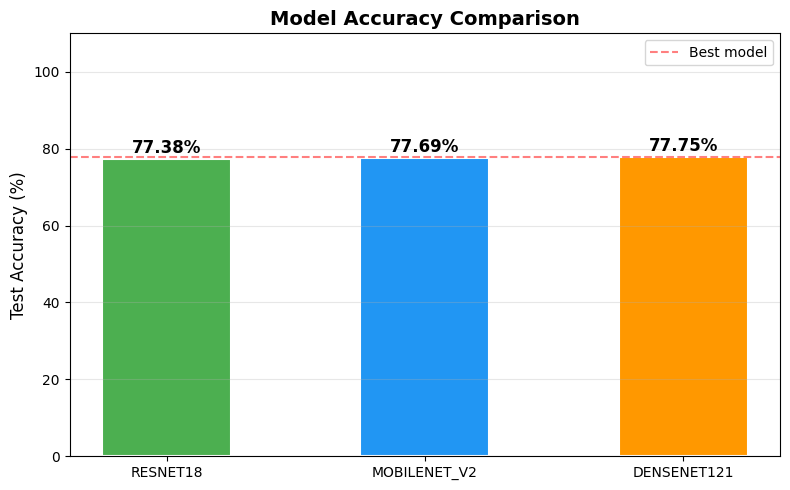

📁 Saved: model_comparison.png


In [38]:
names  = [n.upper() for n in MODEL_NAMES]
accs   = [test_results[n]["acc"] for n in MODEL_NAMES]
colors = ["#4CAF50", "#2196F3", "#FF9800"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor="white", linewidth=1.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{acc:.2f}%",
            ha="center", va="bottom", fontweight="bold", fontsize=12)

ax.set_ylim(0, 110)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
ax.axhline(y=max(accs), color="red", linestyle="--", alpha=0.5, label="Best model")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved: model_comparison.png")

## Step 12: Grad-CAM Visualisation
Highlights the image regions that most influenced each model's decision.


🔥 Running Grad-CAM for resnet18


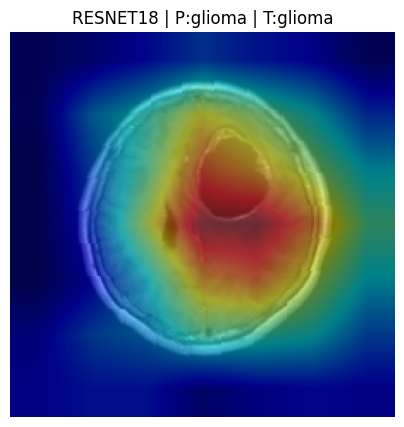


🔥 Running Grad-CAM for mobilenet_v2


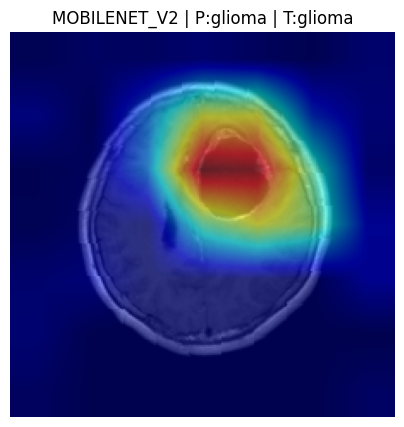


🔥 Running Grad-CAM for densenet121


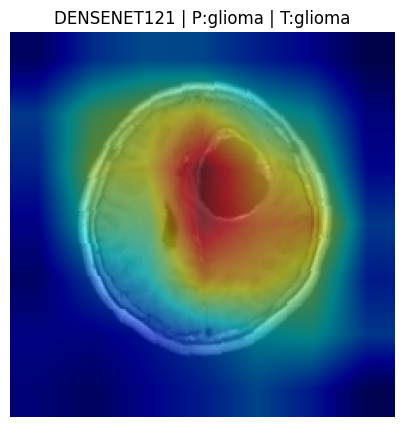

In [39]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np

def apply_gradcam(model, name, images, labels, class_names):
    print(f"\n🔥 Running Grad-CAM for {name}")

    model.eval()

    # 🔥 Force gradients ON
    for param in model.parameters():
        param.requires_grad = True

    # ✅ Correct target layers
    if name == "resnet18":
        target_layers = [model.layer4[-1]]
    elif name == "mobilenet_v2":
        target_layers = [model.features[-1]]
    elif name == "densenet121":
        target_layers = [model.features.denseblock4]

    cam = GradCAM(model=model, target_layers=target_layers)

    # 🔥 ONE image only
    input_tensor = images[0].unsqueeze(0)

    # Forward pass
    outputs = model(input_tensor)
    pred_class = outputs.argmax().item()

    targets = [ClassifierOutputTarget(pred_class)]

    # Generate CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # Prepare image
    img = images[0].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(5,5))
    plt.imshow(visualization)
    plt.title(f"{name.upper()} | P:{class_names[pred_class]} | T:{class_names[labels[0].item()]}")
    plt.axis("off")
    plt.show()
for name, model in trained_models.items():
  apply_gradcam(model, name, images, labels, CLASS_NAMES)

## Step 13: Save Trained Models

In [40]:
os.makedirs("saved_models", exist_ok=True)

for name, model in trained_models.items():
    path = f"saved_models/{name}_brain_tumor.pth"
    torch.save({
        "model_name":   name,
        "state_dict":   model.state_dict(),
        "class_names":  CLASS_NAMES,
        "num_classes":  NUM_CLASSES,
        "img_size":     IMG_SIZE,
        "test_accuracy": test_results[name]["acc"]
    }, path)
    print(f"💾 Saved: {path}  (Acc: {test_results[name]['acc']:.2f}%)")

💾 Saved: saved_models/resnet18_brain_tumor.pth  (Acc: 77.38%)
💾 Saved: saved_models/mobilenet_v2_brain_tumor.pth  (Acc: 77.69%)
💾 Saved: saved_models/densenet121_brain_tumor.pth  (Acc: 77.75%)


## Step 14: Sample Predictions with Confidence

🏆 Best model: DENSENET121 (77.75%)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


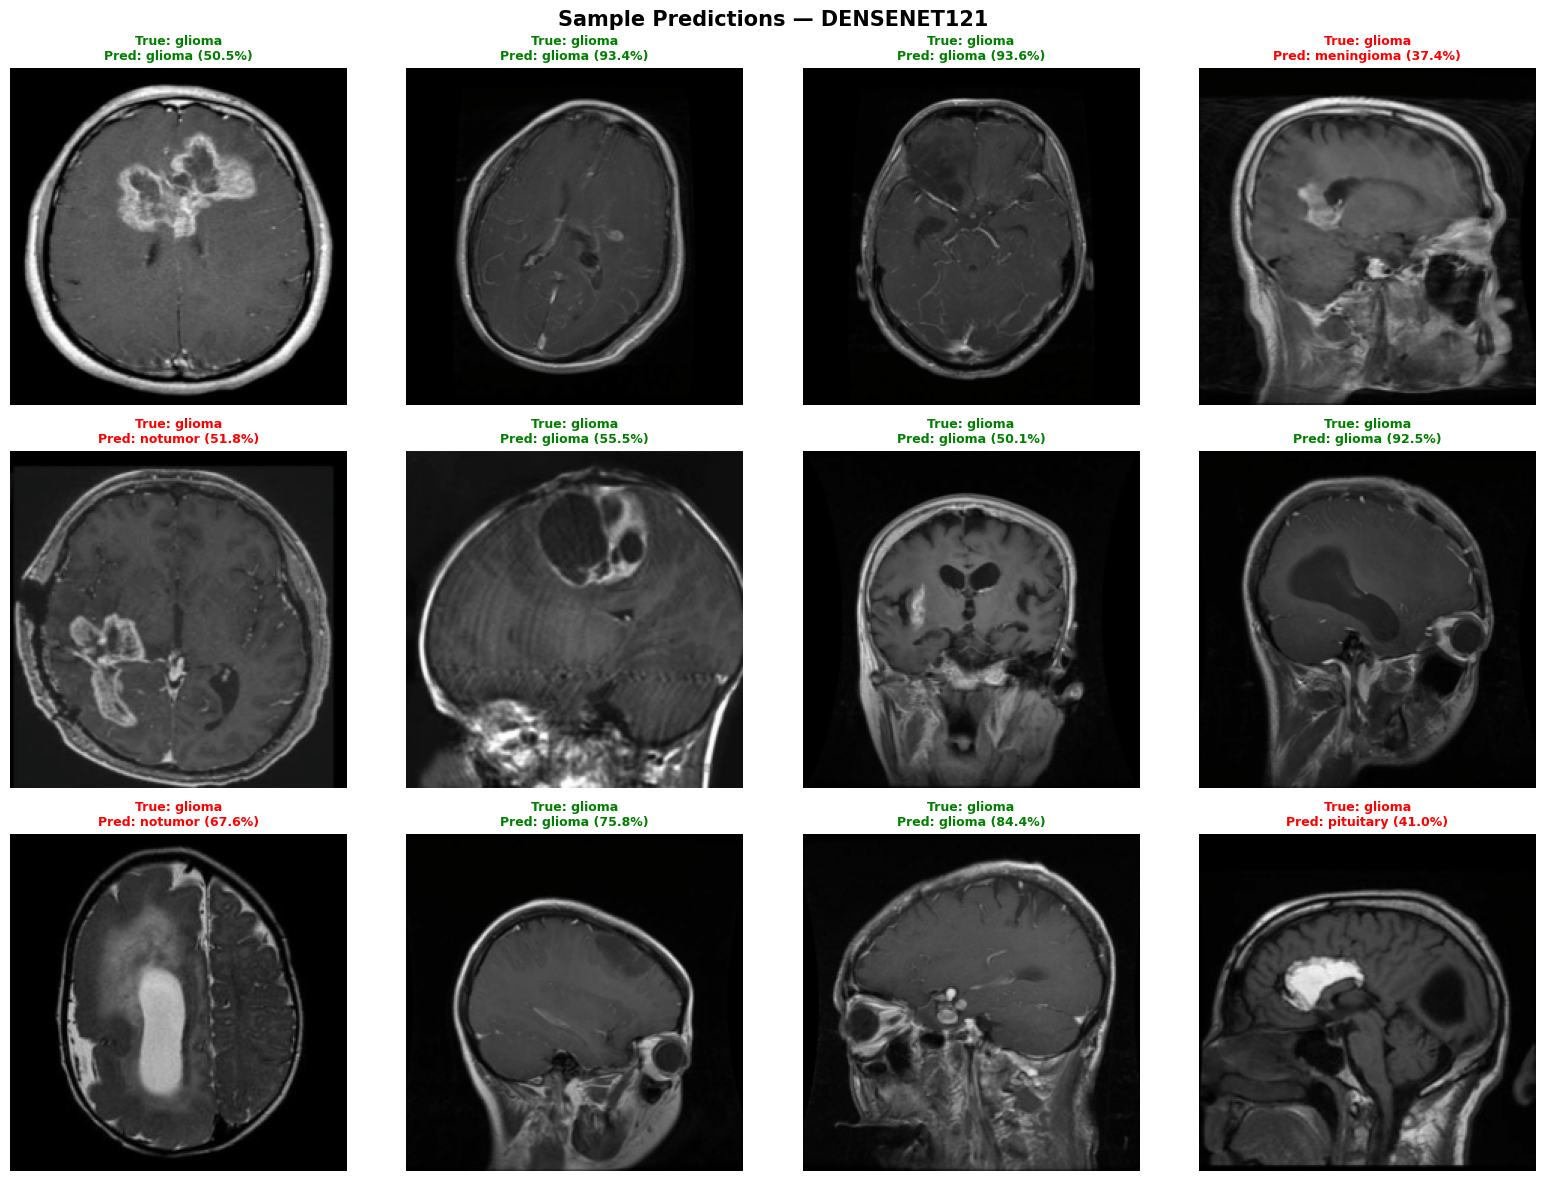

📁 Saved: sample_predictions.png


In [41]:
# Pick the best model by test accuracy
best_model_name = max(test_results, key=lambda k: test_results[k]["acc"])
best_model      = trained_models[best_model_name]
print(f"🏆 Best model: {best_model_name.upper()} "
      f"({test_results[best_model_name]['acc']:.2f}%)")

best_model.eval()
softmax = nn.Softmax(dim=1)

n_show = 12
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(f"Sample Predictions — {best_model_name.upper()}",
             fontsize=15, fontweight="bold")

images_shown = 0
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

with torch.no_grad():
    for images, labels in test_loader:
        outputs = best_model(images.to(DEVICE))
        probs   = softmax(outputs).cpu().numpy()
        preds   = probs.argmax(axis=1)

        for i in range(len(images)):
            if images_shown >= n_show:
                break
            ax = axes[images_shown // 4][images_shown % 4]
            img = images[i].numpy().transpose(1, 2, 0)
            img = std * img + mean
            img = np.clip(img, 0, 1)

            true_label = CLASS_NAMES[labels[i]]
            pred_label = CLASS_NAMES[preds[i]]
            confidence = probs[i][preds[i]] * 100
            colour     = "green" if true_label == pred_label else "red"

            ax.imshow(img)
            ax.set_title(
                f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                fontsize=9, color=colour, fontweight="bold"
            )
            ax.axis("off")
            images_shown += 1

        if images_shown >= n_show:
            break

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved: sample_predictions.png")

## Step 15: Ensemble Model — ResNet18 + DenseNet121

In [46]:
class EnsembleModel(nn.Module):
    """
    Simple soft-voting ensemble:
    averages softmax probabilities from ResNet18 + DenseNet121.
    """
    def __init__(self, model_a, model_b):
        super().__init__()
        self.model_a = model_a
        self.model_b = model_b
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        out_a = self.softmax(self.model_a(x))
        out_b = self.softmax(self.model_b(x))
        return (out_a + out_b) / 2   # averaged probability


ensemble = EnsembleModel(
    trained_models["resnet18"],
    trained_models["densenet121"]
).to(DEVICE)
ensemble.eval()

# Evaluate ensemble
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = ensemble(images.to(DEVICE))
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

ensemble_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\n Ensemble (ResNet18 + DenseNet121) Test Accuracy: {ensemble_acc:.2f}%")
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))

# ── Final leaderboard ────────────────────────────────────────────────────────
print("\n" + "="*40)
print("       FINAL LEADERBOARD")
print("="*40)
for name in MODEL_NAMES:
    acc = test_results[name]["acc"]
    bar = "█" * int(acc / 2)
    print(f"  {name:<14} {acc:6.2f}%  {bar}")
print(f"  {'Ensemble':<14} {ensemble_acc:6.2f}%  {'█' * int(ensemble_acc / 2)}")
print("="*40)


🤝 Ensemble (ResNet18 + DenseNet121) Test Accuracy: 80.19%
              precision    recall  f1-score   support

      glioma     0.8145    0.7575    0.7850       400
  meningioma     0.7742    0.5400    0.6362       400
     notumor     0.7780    0.9900    0.8713       400
   pituitary     0.8364    0.9200    0.8762       400

    accuracy                         0.8019      1600
   macro avg     0.8008    0.8019    0.7922      1600
weighted avg     0.8008    0.8019    0.7922      1600


       FINAL LEADERBOARD
  resnet18        77.38%  ██████████████████████████████████████
  mobilenet_v2    77.69%  ██████████████████████████████████████
  densenet121     77.75%  ██████████████████████████████████████
  Ensemble        80.19%  ████████████████████████████████████████


In [47]:
torch.save({
    "resnet": trained_models["resnet18"].state_dict(),
    "densenet": trained_models["densenet121"].state_dict()
}, "ensemble_model.pth")

In [48]:
checkpoint = torch.load("ensemble_model.pth", map_location="cpu")

resnet = build_model("resnet18")
resnet.load_state_dict(checkpoint["resnet"])

densenet = build_model("densenet121")
densenet.load_state_dict(checkpoint["densenet"])

ensemble = EnsembleModel(resnet, densenet)
ensemble.eval()

EnsembleModel(
  (model_a): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

## 📋 Step 15: Final Summary

In [49]:
print("  BRAIN TUMOR DETECTION — FINAL SUMMARY")
print(f"  Dataset      : {TRAIN_DIR}")
print(f"  Classes      : {CLASS_NAMES}")
print(f"  Image Size   : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Epochs       : {NUM_EPOCHS}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Device       : {DEVICE}")
print()
print("  Individual Models:")
for name in MODEL_NAMES:
    print(f"    {name:<14}: {test_results[name]['acc']:.2f}%")
print(f"    {'Ensemble':<14}: {ensemble_acc:.2f}%")
print()
winner = max(test_results, key=lambda k: test_results[k]["acc"])
if ensemble_acc > test_results[winner]["acc"]:
    winner = "Ensemble"
    win_acc = ensemble_acc
else:
    win_acc = test_results[winner]["acc"]
print(f"  🏆 Best Model: {winner.upper()}  ({win_acc:.2f}%)")
print()
print("  Saved files:")
for name in MODEL_NAMES:
    print(f"    saved_models/{name}_brain_tumor.pth")
print("  training_curves.png")
print("  confusion_matrices.png")
print("  model_comparison.png")
print("  sample_predictions.png")
for name in MODEL_NAMES:
    print(f"  gradcam_{name}.png")

  BRAIN TUMOR DETECTION — FINAL SUMMARY
  Dataset      : /content/dataset/Training
  Classes      : ['glioma', 'meningioma', 'notumor', 'pituitary']
  Image Size   : 224×224
  Epochs       : 1
  Batch Size   : 16
  Device       : cpu

  Individual Models:
    resnet18      : 77.38%
    mobilenet_v2  : 77.69%
    densenet121   : 77.75%
    Ensemble      : 80.19%

  🏆 Best Model: ENSEMBLE  (80.19%)

  Saved files:
    saved_models/resnet18_brain_tumor.pth
    saved_models/mobilenet_v2_brain_tumor.pth
    saved_models/densenet121_brain_tumor.pth
  training_curves.png
  confusion_matrices.png
  model_comparison.png
  sample_predictions.png
  gradcam_resnet18.png
  gradcam_mobilenet_v2.png
  gradcam_densenet121.png
